In [1]:
import anndata as ad
adata = ad.read_h5ad("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/input_files/anndata_objects/KOLF_Pan_Genome_Knockdown_Filtered.h5ad")

In [ ]:
kolf_feature_ref = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/input_files/pan_genome_feature_reference.csv')

NameError: name 'pd' is not defined

Starting screen coverage analysis...
Dataset shape: 1977854 cells, 38606 features

=== PER-PERTURBATION (sgRNA) COVERAGE ANALYSIS ===
Perturbation Coverage Statistics:
perturbation_count: 24863
perturbation_mean_cells: 79.55009451795841
perturbation_median_cells: 74.0
perturbation_iqr_cells: 45.0
perturbation_min_cells: 26
perturbation_max_cells: 338
perturbation_cells_gt_25: 24863
perturbation_pct_gt_25: 100.0

=== PER-TARGET-GENE COVERAGE ANALYSIS ===
Target Gene Coverage Statistics:
gene_count: 10167
gene_mean_cells: 191.05242451067178
gene_median_cells: 186.0
gene_iqr_cells: 128.0
gene_min_cells: 26
gene_max_cells: 732
gene_cells_gt_25: 10167
gene_pct_gt_25: 100.0
NTC count: 35424

=== BATCH-LEVEL ANALYSIS ===
Cells per Perturbation by batch:
            mean  median        std  count
batch                                     
ALPHA  85.646521    82.0  33.423555   7661
BETA   86.245038    80.0  36.434468   9019
GAMMA  63.248285    57.0  28.890177   8599

Cells per Gene Target by ba

/scratch/ydoctor/job_8153098/ipykernel_22212/600805243.py:197: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_perturbation_summary = batch_results['batch_perturbation'].groupby('batch')['cell_count'].agg(['mean', 'median', 'std', 'count'])
/scratch/ydoctor/job_8153098/ipykernel_22212/600805243.py:201: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_gene_summary = batch_results['batch_gene'].groupby('batch')['cell_count'].agg(['mean', 'median', 'std', 'count'])


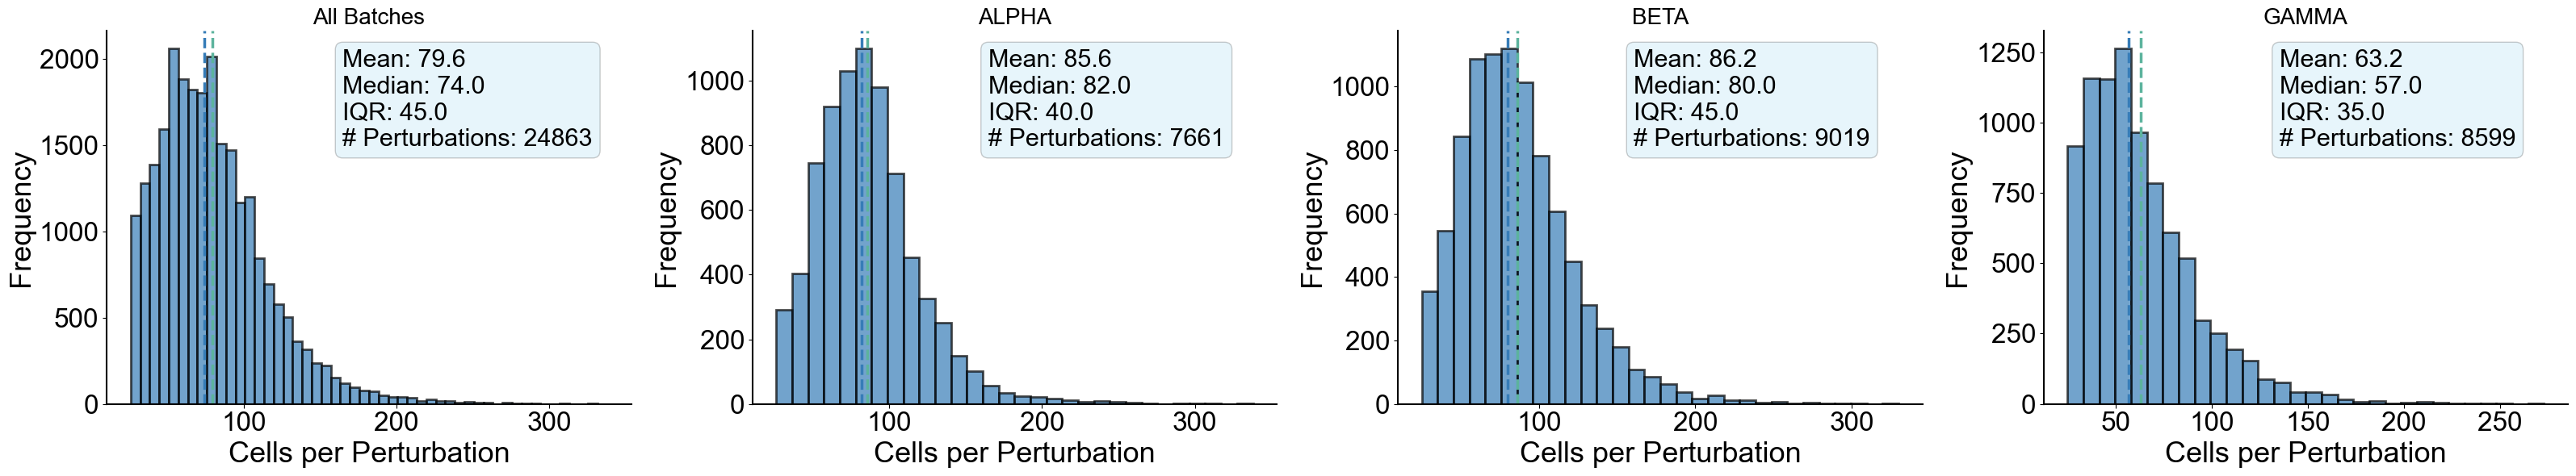

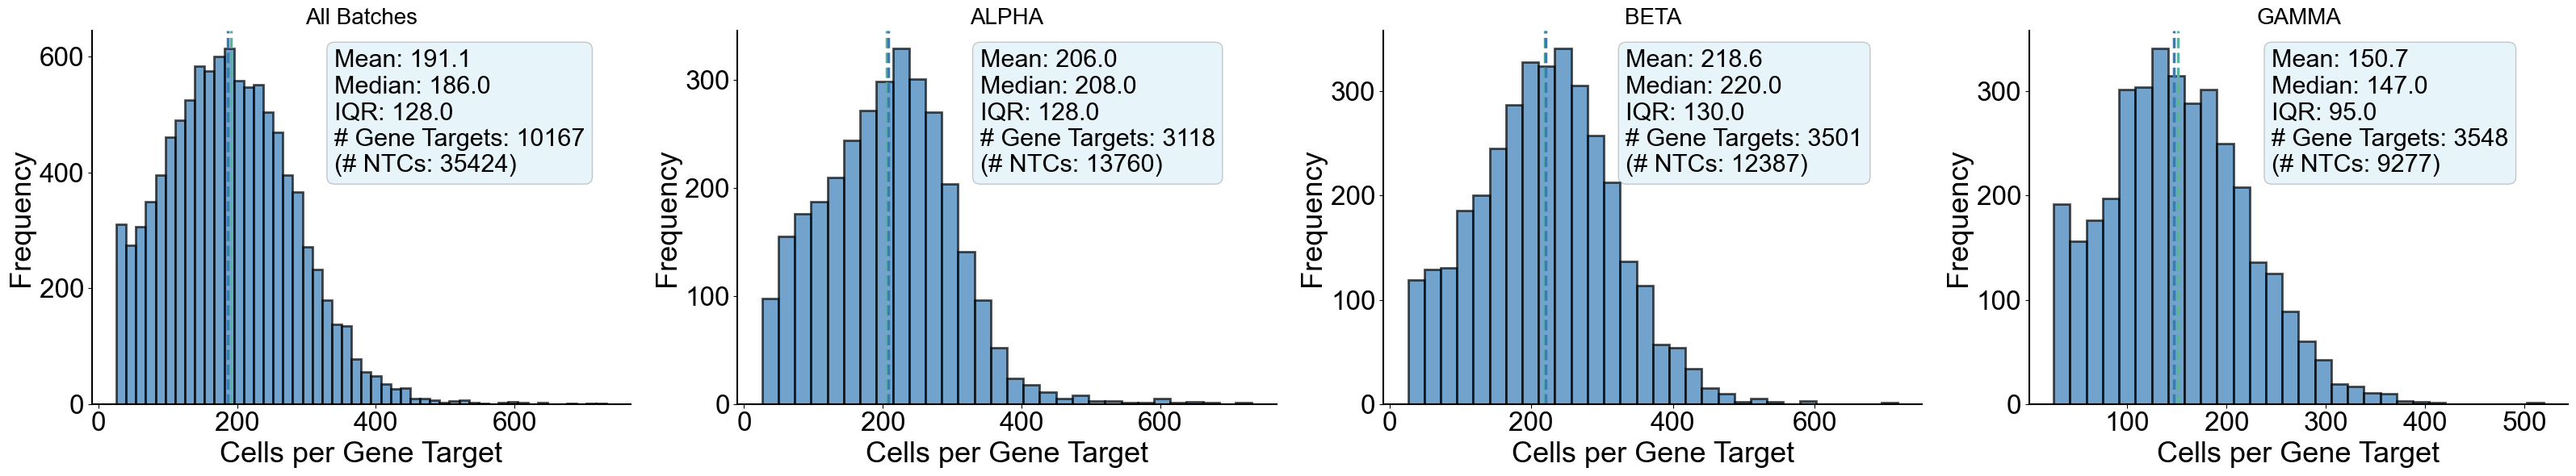


=== SUMMARY TABLES ===

Overall Summary:
          Metric    Count
0    Total Cells  1977854
1  Perturbations    24863
2   Target Genes    10167
3        Batches        3

Detailed Coverage Statistics:
      Coverage_Type  Mean_Cells  Median_Cells  IQR_Cells  Min_Cells  \
0  Per-perturbation   79.550095          74.0       45.0         26   
1   Per-target-gene  191.052425         186.0      128.0         26   

   Max_Cells  Count_gt_25_cells  Pct_gt_25_cells  
0        338              24863            100.0  
1        732              10167            100.0  

Analysis complete! Check the generated PNG files for visualizations.


In [22]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set up plotting style
plt.style.use('default')
plt.rcParams["font.family"] = "Arial"
sns.set_palette("husl")


# ============================================================================
# PLACEHOLDER VARIABLES - FILL IN WITH ACTUAL COLUMN NAMES FROM adata.obs
# ============================================================================

# Column containing perturbation/guide/sgRNA identifiers (e.g., 'guide_id', 'perturbation_id')
PERTURBATION_COL = 'gRNA'

# Column containing target gene names (e.g., 'gene_symbol', 'target_gene')
TARGET_GENE_COL = 'gene_target'

# Column containing batch/sample information (e.g., 'batch', 'sample_id', 'experiment')
BATCH_COL = 'batch'

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def calculate_coverage_stats(grouped_data, group_name):
    """Calculate mean, median, IQR for coverage distributions"""
    counts = grouped_data.size()
    stats_dict = {
        f'{group_name}_count': len(counts),
        f'{group_name}_mean_cells': counts.mean(),
        f'{group_name}_median_cells': counts.median(),
        f'{group_name}_iqr_cells': counts.quantile(0.75) - counts.quantile(0.25),
        f'{group_name}_min_cells': counts.min(),
        f'{group_name}_max_cells': counts.max(),
        f'{group_name}_cells_gt_25': (counts > 25).sum(),
        f'{group_name}_pct_gt_25': (counts > 25).sum() / len(counts) * 100
    }
    return stats_dict, counts

def plot_single_histogram(ax, counts, title, xlabel, n_unique_label, n_unique, n_ntc=None):
    """Helper function to plot a single histogram on an axis"""
    # Calculate statistics
    mean_val = counts.mean()
    median_val = counts.median()
    q25 = counts.quantile(0.25)
    q75 = counts.quantile(0.75)
    iqr_val = q75 - q25

    # Histogram
    ax.hist(counts, bins=50, alpha=0.7, color='#367CB7', edgecolor='black', linewidth=2)
    ax.set_xlabel(xlabel, fontsize=26)
    ax.set_ylabel('Frequency', fontsize=26)
    ax.set_title(title, fontsize=20)
    # Set tick label font sizes to be larger
    ax.tick_params(axis='both', which='major', labelsize=24)

    # Style the axes to match sample code
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=24)

    # Add reference lines with thicker lines (no labels to avoid duplicate legend)
    ax.axvline(mean_val, color='#5CB39D', linestyle='--', linewidth=2.5)
    ax.axvline(median_val, color='#367CB7', linestyle='--', linewidth=2.5)

    # Add text annotations with statistics including number of unique items
    textstr = f'Mean: {mean_val:.1f}\nMedian: {median_val:.1f}\nIQR: {iqr_val:.1f}\n{n_unique_label}: {n_unique}'
    if n_ntc is not None:
        textstr += f'\n(# NTCs: {n_ntc})'
    props = dict(boxstyle='round', facecolor='skyblue', alpha=0.2)
    ax.text(0.45, 0.95, textstr, transform=ax.transAxes, fontsize=22,
            verticalalignment='top', bbox=props)

def analyze_coverage_by_batch(adata, perturbation_col, target_gene_col, batch_col):
    """Analyze cells per sgRNA and cells per target gene by batch"""
    results = {}

    # Group by batch and perturbation (sgRNA level) - only perturbations present in each batch
    batch_perturbation_counts = adata.obs.groupby([batch_col, perturbation_col], observed=True).size()
    results['batch_perturbation'] = batch_perturbation_counts.reset_index(name='cell_count')

    # Group by batch and target gene (aggregated across guides) - only genes present in each batch
    # Filter out 'NTC' for gene analysis
    adata_filtered = adata[adata.obs[target_gene_col] != 'NTC']
    batch_gene_counts = adata_filtered.obs.groupby([batch_col, target_gene_col], observed=True).size()
    results['batch_gene'] = batch_gene_counts.reset_index(name='cell_count')

    return results

def plot_batch_coverage_with_overall(overall_counts, batch_data, title, xlabel, n_unique_label, n_ntc=None, batch_ntc_counts=None, save_path=None):
    """Plot coverage distributions with overall as first panel, then batches"""
    batches = batch_data['batch'].unique()
    n_batches = len(batches)
    n_cols = n_batches + 1  # Overall + batches
    fig, axes = plt.subplots(1, n_cols, figsize=(8*n_cols, 6))
    
    # Handle case where there's only one column (shouldn't happen but safe)
    if n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # First panel: Overall
    plot_single_histogram(axes[0], overall_counts, 'All Batches', xlabel, n_unique_label, len(overall_counts), n_ntc)
    
    # Remaining panels: Individual batches
    for i, batch in enumerate(batches):
        batch_subset = batch_data[batch_data['batch'] == batch]
        
        # Calculate statistics
        mean_val = batch_subset['cell_count'].mean()
        median_val = batch_subset['cell_count'].median()
        q25 = batch_subset['cell_count'].quantile(0.25)
        q75 = batch_subset['cell_count'].quantile(0.75)
        iqr_val = q75 - q25
        n_unique = len(batch_subset)
        
        axes[i+1].hist(batch_subset['cell_count'], bins=30, alpha=0.7, color='#367CB7', edgecolor='black', linewidth=2)
        axes[i+1].set_xlabel(xlabel, fontsize=26)
        axes[i+1].set_ylabel('Frequency', fontsize=26)
        axes[i+1].set_title(f'{batch}', fontsize=20)

        # Style the axes to match sample code
        axes[i+1].set_facecolor('white')
        axes[i+1].spines['top'].set_visible(False)
        axes[i+1].spines['right'].set_visible(False)
        axes[i+1].spines['bottom'].set_linewidth(1.5)
        axes[i+1].spines['left'].set_linewidth(1.5)
        axes[i+1].grid(False)
        axes[i+1].tick_params(axis='both', which='major', labelsize=24)

        # Add reference lines with thicker lines
        axes[i+1].axvline(mean_val, color='#5CB39D', linestyle='--', linewidth=2.5)
        axes[i+1].axvline(median_val, color='#367CB7', linestyle='--', linewidth=2.5)
        
        # Add text annotations with statistics including number of unique items
        textstr = f'Mean: {mean_val:.1f}\nMedian: {median_val:.1f}\nIQR: {iqr_val:.1f}\n{n_unique_label}: {n_unique}'
        if batch_ntc_counts is not None and batch in batch_ntc_counts:
            textstr += f'\n(# NTCs: {batch_ntc_counts[batch]})'
        props = dict(boxstyle='round', facecolor='skyblue', alpha=0.2)
        axes[i+1].text(0.45, 0.95, textstr, transform=axes[i+1].transAxes, fontsize=22,
                    verticalalignment='top', bbox=props)
        

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

print("Starting screen coverage analysis...")
print(f"Dataset shape: {adata.shape[0]} cells, {adata.shape[1]} features")

# 1. Per-perturbation (sgRNA) cell coverage analysis
print("\n=== PER-PERTURBATION (sgRNA) COVERAGE ANALYSIS ===")
perturbation_stats, perturbation_counts = calculate_coverage_stats(
    adata.obs.groupby(PERTURBATION_COL, observed=True), 'perturbation'
)

print("Perturbation Coverage Statistics:")
for key, value in perturbation_stats.items():
    print(f"{key}: {value}")

# 2. Per-target-gene cell coverage analysis (excluding NTC)
print("\n=== PER-TARGET-GENE COVERAGE ANALYSIS ===")
adata_no_ntc = adata[adata.obs[TARGET_GENE_COL] != 'NTC']
gene_stats, gene_counts = calculate_coverage_stats(
    adata_no_ntc.obs.groupby(TARGET_GENE_COL, observed=True), 'gene'
)

# Count NTCs
ntc_count = (adata.obs[TARGET_GENE_COL] == 'NTC').sum()

print("Target Gene Coverage Statistics:")
for key, value in gene_stats.items():
    print(f"{key}: {value}")
print(f"NTC count: {ntc_count}")

# 3. Batch-level analysis
print("\n=== BATCH-LEVEL ANALYSIS ===")
batch_results = analyze_coverage_by_batch(adata, PERTURBATION_COL, TARGET_GENE_COL, BATCH_COL)

print("Cells per Perturbation by batch:")
batch_perturbation_summary = batch_results['batch_perturbation'].groupby('batch')['cell_count'].agg(['mean', 'median', 'std', 'count'])
print(batch_perturbation_summary)

print("\nCells per Gene Target by batch:")
batch_gene_summary = batch_results['batch_gene'].groupby('batch')['cell_count'].agg(['mean', 'median', 'std', 'count'])
print(batch_gene_summary)

# Plot combined perturbation distributions (overall + batches)
plot_batch_coverage_with_overall(
    perturbation_counts,
    batch_results['batch_perturbation'],
    'Cells per Perturbation',
    'Cells per Perturbation',
    '# Perturbations',
    n_ntc=None,
    save_path='/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/perturbation_coverage_combined.svg'
)

# Plot combined gene target distributions (overall + batches)
# For batch gene data, we need to count NTCs per batch
batch_ntc_counts = {}
for batch in batch_results['batch_gene']['batch'].unique():
    batch_adata = adata[adata.obs[BATCH_COL] == batch]
    batch_ntc_counts[batch] = (batch_adata.obs[TARGET_GENE_COL] == 'NTC').sum()

plot_batch_coverage_with_overall(
    gene_counts,
    batch_results['batch_gene'],
    'Cells per Gene Target',
    'Cells per Gene Target',
    '# Gene Targets',
    n_ntc=ntc_count,
    batch_ntc_counts=batch_ntc_counts,
    save_path='/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/gene_target_coverage_combined.svg'
)

# ============================================================================
# SUMMARY TABLES
# ============================================================================

print("\n=== SUMMARY TABLES ===")

# Overall coverage summary
summary_df = pd.DataFrame({
    'Metric': ['Total Cells', 'Perturbations', 'Target Genes', 'Batches'],
    'Count': [
        len(adata.obs),
        perturbation_stats['perturbation_count'],
        gene_stats['gene_count'],
        adata.obs[BATCH_COL].nunique()
    ]
})
print("\nOverall Summary:")
print(summary_df)

# Detailed coverage statistics
detailed_stats = pd.DataFrame({
    'Coverage_Type': ['Per-perturbation', 'Per-target-gene'],
    'Mean_Cells': [perturbation_stats['perturbation_mean_cells'], gene_stats['gene_mean_cells']],
    'Median_Cells': [perturbation_stats['perturbation_median_cells'], gene_stats['gene_median_cells']],
    'IQR_Cells': [perturbation_stats['perturbation_iqr_cells'], gene_stats['gene_iqr_cells']],
    'Min_Cells': [perturbation_stats['perturbation_min_cells'], gene_stats['gene_min_cells']],
    'Max_Cells': [perturbation_stats['perturbation_max_cells'], gene_stats['gene_max_cells']],
    'Count_gt_25_cells': [perturbation_stats['perturbation_cells_gt_25'], gene_stats['gene_cells_gt_25']],
    'Pct_gt_25_cells': [perturbation_stats['perturbation_pct_gt_25'], gene_stats['gene_pct_gt_25']]
})
print("\nDetailed Coverage Statistics:")
print(detailed_stats)

print("\nAnalysis complete! Check the generated PNG files for visualizations.")

In [4]:
adata_perturbed = adata[adata.obs['perturbation'] != 'NTC']
perturbation_counts = adata_perturbed.obs['perturbation'].value_counts()

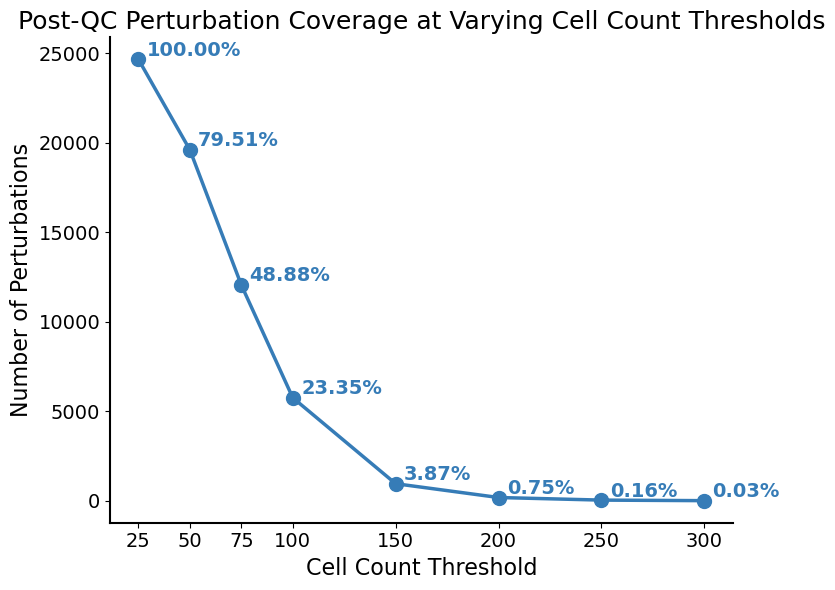

In [6]:
import matplotlib.pyplot as plt
import numpy as np
thresholds = [25, 50, 75, 100, 150, 200, 250, 300]
num_perturbations = []
percent_perturbations = []

total = len(perturbation_counts)

for t in thresholds:
    n = (perturbation_counts >= t).sum()
    pct = 100 * n / total
    num_perturbations.append(n)
    percent_perturbations.append(pct)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot number of perturbations
ax.plot(thresholds, num_perturbations, color='#367CB7', marker='o', linewidth=2.5, markersize=10)
ax.set_xlabel('Cell Count Threshold', fontsize=16)
ax.set_ylabel('Number of Perturbations', fontsize=16)
ax.set_xticks(thresholds)
ax.set_title('Post-QC Perturbation Coverage at Varying Cell Count Thresholds', fontsize=18)

# Style the axes to match sample code
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.grid(False)
ax.tick_params(axis='both', which='major', labelsize=14)

# Add percentage labels on data points
for i, (x, y) in enumerate(zip(thresholds, num_perturbations)):
    ax.text(x+4, y+200, f'{percent_perturbations[i]:.2f}%', color='#367CB7', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/perturbation_coverage_by_cell_count.svg', dpi=300)
plt.show()


In [9]:
import pandas as pd
etest_results = pd.read_csv("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/output_files/etest_results.csv", index_col=0)
etest_results = etest_results.merge(
    perturbation_counts.rename('n_cells'),
    left_index=True, right_index=True, how='left'
)
etest_results['log1p_edist'] = np.log1p(etest_results['edist'].replace([np.inf, -np.inf, np.nan], 0))

/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
etest_results

,edist,pvalue,significant,pvalue_adj,significant_adj,neglog10_pvalue_adj,batch,cross_batch_pvalue_adj,cross_batch_significant,cross_batch_neglog10_pvalue_adj,n_cells,log1p_edist
ARHGAP35_2,0.470008,0.1594,False,0.347260,False,0.459346,ALPHA,0.244525,False,0.611677,168.0,0.385268
AARS2_2,5.121626,0.0021,True,0.035070,True,1.455064,ALPHA,0.014503,True,1.838544,84.0,1.811828
ACSM3_1,0.301312,0.2985,False,0.461569,False,0.335763,ALPHA,0.383129,False,0.416655,65.0,0.263373
AGO2_1,-0.314267,0.5379,False,0.629645,False,0.200904,ALPHA,0.598814,False,0.222708,66.0,-0.377266
BHLHA9_1,5.194333,0.0035,True,0.047531,True,1.323025,ALPHA,0.019943,True,1.700214,71.0,1.823635
...,...,...,...,...,...,...,...,...,...,...,...,...
ZC3H18_2,12.396693,0.0003,True,0.010691,True,1.970985,GAMMA,0.003903,True,2.408583,40.0,2.595008
WASF3_3,-0.164231,0.4569,False,0.554504,False,0.256095,GAMMA,0.528892,False,0.276633,35.0,-0.179403
VCAN_1,-0.812420,0.6151,False,0.686445,False,0.163394,GAMMA,0.666284,False,0.176341,35.0,-1.673550
VSNL1_1,2.995471,0.0690,False,0.198003,False,0.703328,GAMMA,0.137381,False,0.862072,38.0,1.385161


/scratch/ydoctor/job_8571088/ipykernel_3320796/3980386913.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/ydoctor/job_8571088/ipykernel_3320796/3980386913.py:20: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


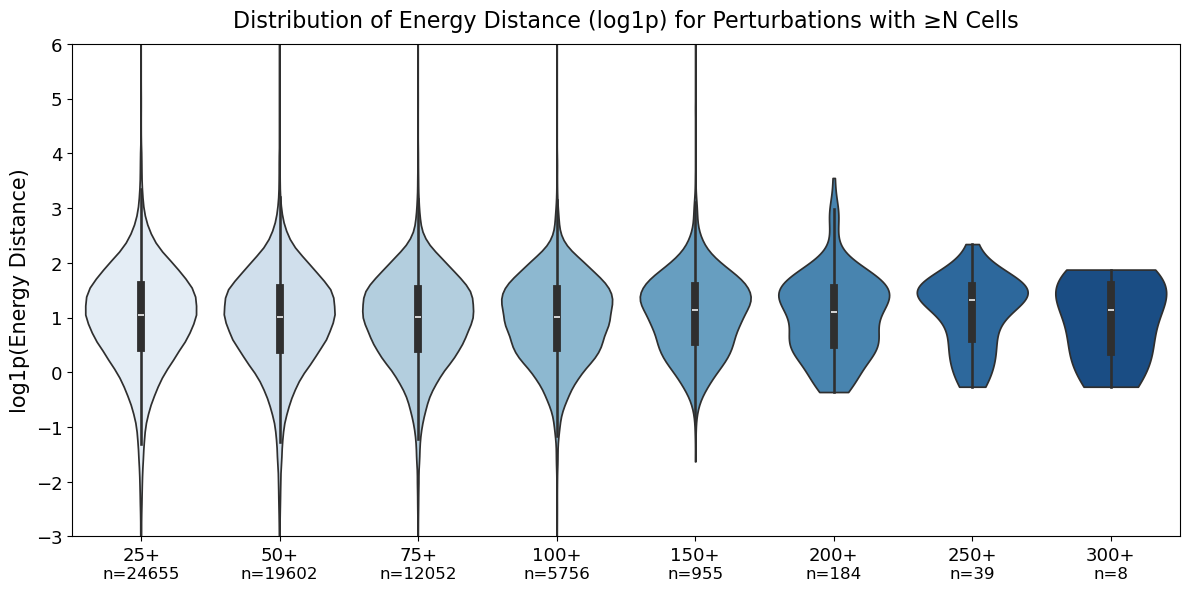

In [12]:
import seaborn as sns

# Use unique "threshold" values as labels for x-axis, and avoid duplicate index issues
thresholds = [25, 50, 75, 100, 150, 200, 250, 300]
violin_data = []
pert_counts = []  # To store number of perts >= threshold

for t in thresholds:
    # Create a fresh copy and add a column for the threshold label
    subset = etest_results[etest_results['n_cells'] >= t].copy()
    subset = subset.reset_index(drop=True)  # Reset the index to ensure uniqueness
    subset['threshold'] = f"{t}+"
    violin_data.append(subset)
    pert_counts.append(subset.shape[0])

# Concatenate and ensure index is a default RangeIndex (no duplicates)
violin_df = pd.concat(violin_data, axis=0, ignore_index=True)

plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    x='threshold', y='log1p_edist',
    data=violin_df,
    order=[f"{t}+" for t in thresholds],
    palette='Blues',
    scale='width',
    cut=0
)


plt.ylabel("log1p(Energy Distance)", fontsize=15)
plt.xlabel("", fontsize=15)
plt.title("Distribution of Energy Distance (log1p) for Perturbations with ≥N Cells", fontsize=16, pad=12)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(-3,6)
# Annotate the total number of perts per threshold value under each x-axis label
for tick, count in enumerate(pert_counts):
    ax.text(
        tick, ax.get_ylim()[0] -0.06 * (ax.get_ylim()[1] - ax.get_ylim()[0]),  # Just below the plot
        f'n={count}',
        horizontalalignment='center',
        verticalalignment='top',
        fontsize=12,
        color='black'
    )

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/perturbation_edist_by_perturbation_cell_count.svg', dpi=300)
plt.show()

/scratch/ydoctor/job_8571088/ipykernel_3320796/925585522.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/scratch/ydoctor/job_8571088/ipykernel_3320796/925585522.py:20: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


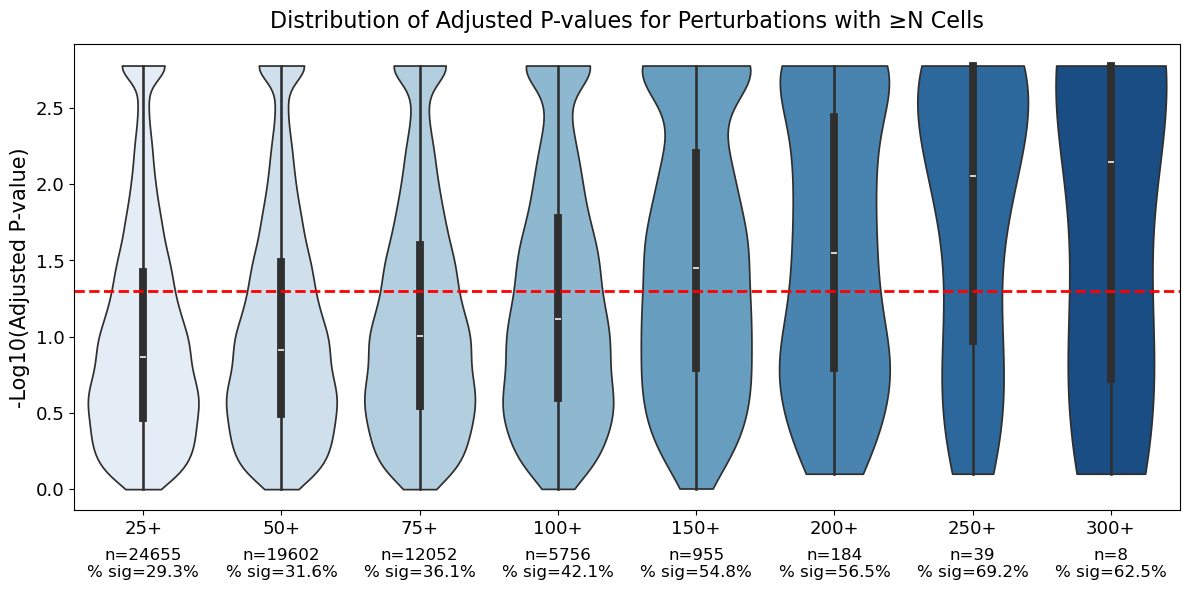

In [13]:
import seaborn as sns

# Use unique "threshold" values as labels for x-axis, and avoid duplicate index issues
thresholds = [25, 50, 75, 100, 150, 200, 250, 300]
violin_data = []
pert_counts = []  # To store number of perts >= threshold

for t in thresholds:
    # Create a fresh copy and add a column for the threshold label
    subset = etest_results[etest_results['n_cells'] >= t].copy()
    subset = subset.reset_index(drop=True)  # Reset the index to ensure uniqueness
    subset['threshold'] = f"{t}+"
    violin_data.append(subset)
    pert_counts.append(subset.shape[0])

# Concatenate and ensure index is a default RangeIndex (no duplicates)
violin_df = pd.concat(violin_data, axis=0, ignore_index=True)

plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    x='threshold', y='cross_batch_neglog10_pvalue_adj',
    data=violin_df,
    order=[f"{t}+" for t in thresholds],
    palette='Blues',
    scale='width',
    cut=0
)

plt.xlabel("", fontsize=15)
plt.ylabel("-Log10(Adjusted P-value)", fontsize=15)
plt.title("Distribution of Adjusted P-values for Perturbations with ≥N Cells", fontsize=16, pad=12)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
pval_threshold = -np.log10(0.05)
plt.axhline(y=pval_threshold, color='red', linestyle='--', linewidth=2)
# Annotate the total number of perts per threshold value and % significant per threshold under each x-axis label
for tick, (t, count) in enumerate(zip(thresholds, pert_counts)):
    subset = etest_results[etest_results['n_cells'] >= t]
    num_sig = (subset['cross_batch_neglog10_pvalue_adj'] > pval_threshold).sum()
    percent_sig = (num_sig / max(1, count)) * 100  # avoid division by zero
    label = f"n={count}\n% sig={percent_sig:.1f}%"
    ax.text(
        tick, ax.get_ylim()[0] - 0.08 * (ax.get_ylim()[1] - ax.get_ylim()[0]),  # Lower for larger label
        label,
        horizontalalignment='center',
        verticalalignment='top',
        fontsize=12,
        color='black'
    )

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/perturbation_edist_pval_by_perturbation_cell_count.svg', dpi=300)
plt.show()

In [2]:
import sys
import os

repo_root = "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import psp

/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML


In [3]:
adata_200 = adata[adata.obs['perturbation'].map(adata.obs['perturbation'].value_counts()) >= 200,:]

In [4]:
import numpy as np
import pandas as pd

def subsample_adata_by_perturbation(adata, n=200, seed=42, pert_key="perturbation", NTC_name="NTC"):
    """
    Subsample AnnData object to n cells per perturbation (except for NTC, which keeps all).
    
    Parameters:
        adata: AnnData object
        n (int): Number of cells to sample per perturbation.
        seed (int): Random seed for reproducibility.
        pert_key (str): Column in adata.obs with perturbation assignments.
        NTC_name (str): Name of the NTC control perturbation.
        
    Returns:
        AnnData: Subsampled AnnData object.
    """
    np.random.seed(seed)
    selected_indices = []
    for pert, group in adata.obs.groupby(pert_key):
        if pert == NTC_name:
            selected_indices.extend(group.index)
        else:
            if len(group) > n:
                chosen = np.random.choice(group.index, size=n, replace=False)
                selected_indices.extend(chosen)
            else:
                selected_indices.extend(group.index)
    return adata[selected_indices, :].copy()

adata_subsampled_200 = subsample_adata_by_perturbation(adata_200, n=200, seed=42, pert_key="perturbation", NTC_name="NTC")
estats_200 = psp.da.compute_etest(adata_subsampled_200)
del adata_subsampled_200
adata_subsampled_150 = subsample_adata_by_perturbation(adata_200, n=150, seed=42, pert_key="perturbation", NTC_name="NTC")
estats_150 = psp.da.compute_etest(adata_subsampled_150)
del adata_subsampled_150
adata_subsampled_100 = subsample_adata_by_perturbation(adata_200, n=100, seed=42, pert_key="perturbation", NTC_name="NTC")
estats_100 = psp.da.compute_etest(adata_subsampled_100)
del adata_subsampled_100
adata_subsampled_50 = subsample_adata_by_perturbation(adata_200, n=50, seed=42, pert_key="perturbation", NTC_name="NTC")
estats_50 = psp.da.compute_etest(adata_subsampled_50)
del adata_subsampled_50
adata_subsampled_25 = subsample_adata_by_perturbation(adata_200, n=25, seed=42, pert_key="perturbation", NTC_name="NTC")
estats_25 = psp.da.compute_etest(adata_subsampled_25)
del adata_subsampled_25


Processing batch: GAMMA - 13677 cells
filtered out 10556 genes that are detected in less than 3 cells
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


computing PCA
    with n_comps=50
    finished (0:00:03)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:18)
    computed connectivities (0:00:01)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:20)
  Processing perturbations 1-22 of 22


  0%|          | 0/10000 [00:00<?, ?it/s]

Processing batch: ALPHA - 27960 cells
filtered out 8565 genes that are detected in less than 3 cells
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


...

Processing batch: BETA - 14662 cells
filtered out 10587 genes that are detected in less than 3 cells
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)


/tscc/nfs/home/ydoctor/miniconda3/envs/perturb_seq_env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


computing PCA
    with n_comps=50
    finished (0:00:12)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PCs', the loadings (adata.varm)
    'pca_variance', the variance / eigenvalues (adata.uns['pca'])
    'pca_variance_ratio', the variance ratio (adata.uns['pca'])
computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 50
    computed neighbors (0:00:02)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
  Processing perturbations 1-91 of 91


  0%|          | 0/10000 [00:00<?, ?it/s]

Cross-batch correction (fdr_bh):
  • Significant perturbations: 11/184 (5.98%)
  • Alpha threshold: 0.05
  • Control entries excluded from correction: 3
  • Total entries examined: 187
Cross-batch correction (fdr_bh):
  • Significant perturbations: 11/187 (5.88%)
  • Alpha threshold: 0.05
E-test results stored in AnnData:
  • adata.uns['etest_results'] - Complete results DataFrame
  • adata.obs['perturbation_edist'] - Energy distance for each cell's perturbation
  • adata.obs['perturbation_pvalue'] - P-value for each cell's perturbation (batch-specific)
  • adata.obs['perturbation_significant'] - Whether cell's perturbation is significant (batch-specific)
  • adata.obs['perturbation_cross_batch_pvalue'] - Cross-batch corrected p-value
  • adata.obs['perturbation_cross_batch_significant'] - Cross-batch significance


In [ ]:
estats_200
estats_150
estats_100
estats_50
estats_25

,edist,pvalue,significant,pvalue_adj,significant_adj,neglog10_pvalue_adj,batch,cross_batch_pvalue_adj,cross_batch_significant,cross_batch_neglog10_pvalue_adj
ABCD1_1,5.618195,0.0002,True,0.002300,True,2.638272,GAMMA,0.001600,True,2.795880
AGTPBP1_3,-0.369556,0.6613,False,0.724281,False,0.140093,GAMMA,0.695310,False,0.157822
CCDC74A_3,1.144556,0.0683,False,0.157090,False,0.803851,GAMMA,0.108338,False,0.965219
CEP78_3,-0.163760,0.5313,False,0.610995,False,0.213962,GAMMA,0.579546,False,0.236912
CTAGE15_3,0.432845,0.2211,False,0.363236,False,0.439811,GAMMA,0.295724,False,0.529114
...,...,...,...,...,...,...,...,...,...,...
UBXN6_3,1.839185,0.0316,True,0.035454,True,1.450339,BETA,0.054853,False,1.260801
USP28_3,5.512800,0.0007,True,0.002221,True,2.653512,BETA,0.003680,True,2.434152
VPS37C_2,7.034541,0.0001,True,0.000613,True,3.212303,BETA,0.000968,True,3.013936
ZFAND2B_2,4.819706,0.0014,True,0.003481,True,2.458286,BETA,0.005724,True,2.242267


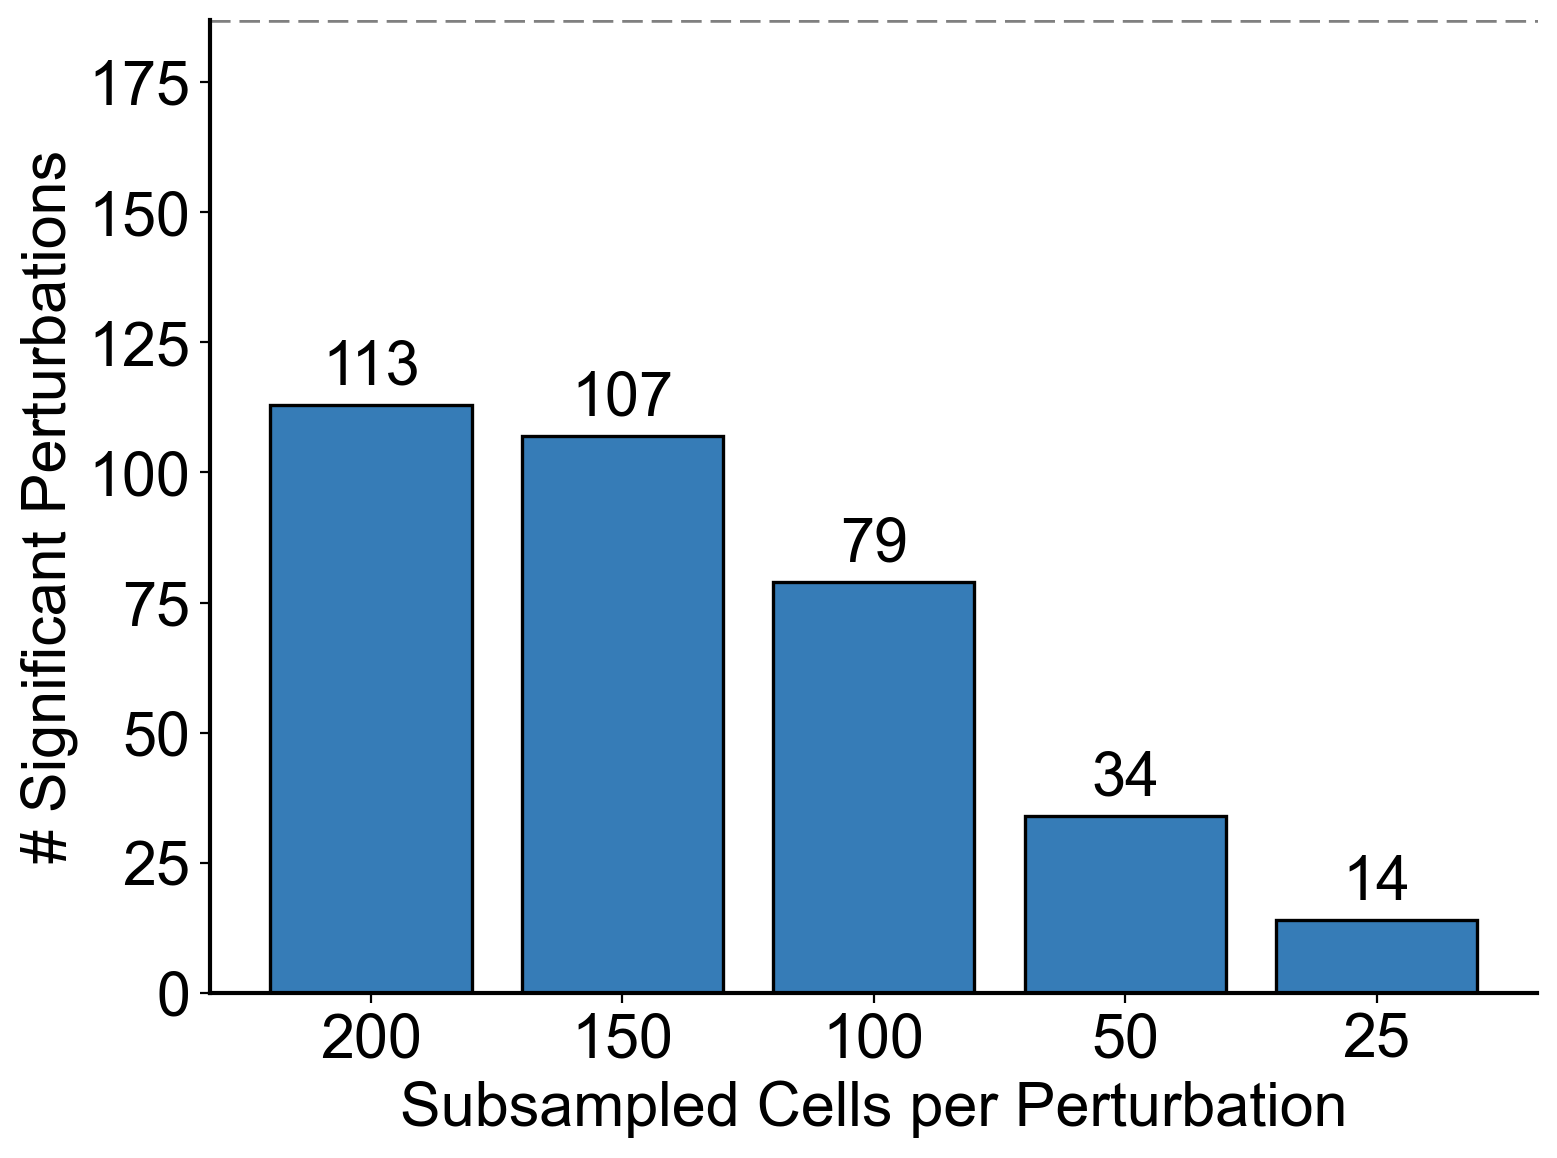

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect counts of cross_batch_significant per DataFrame
estats_dfs = {
    "estats_200": estats_200,
    "estats_150": estats_150,
    "estats_100": estats_100,
    "estats_50": estats_50,
    "estats_25": estats_25,
}


def count_cross_batch_significant(df: pd.DataFrame) -> int:
    if "cross_batch_significant" not in df.columns:
        return 0
    col = df["cross_batch_significant"]
    if pd.api.types.is_bool_dtype(col):
        return int(col.sum())
    return int(col.astype(bool).sum())

# Updated x labels as requested
labels = ["200", "150", "100", "50", "25"]
values = [count_cross_batch_significant(estats_dfs[k]) for k in estats_dfs.keys()]

# Bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color="#367CB7", edgecolor="black", linewidth=1.2)
plt.ylabel("# Significant Perturbations", fontsize=22)
plt.xlabel("Subsampled Cells per Perturbation", fontsize=22)
plt.xticks(rotation=0, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0, 187)  # Set y-limit as requested

# Add horizontal line at y=187
plt.axhline(187, color="gray", linestyle="--", linewidth=2, zorder=0)

# Style similar to other figures
ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(False)

# Annotate counts on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.01 + 0.5,
            f"{val}", ha="center", va="bottom", fontsize=22)

plt.tight_layout()
plt.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/significant_perturbations_by_cells.svg")
plt.show()


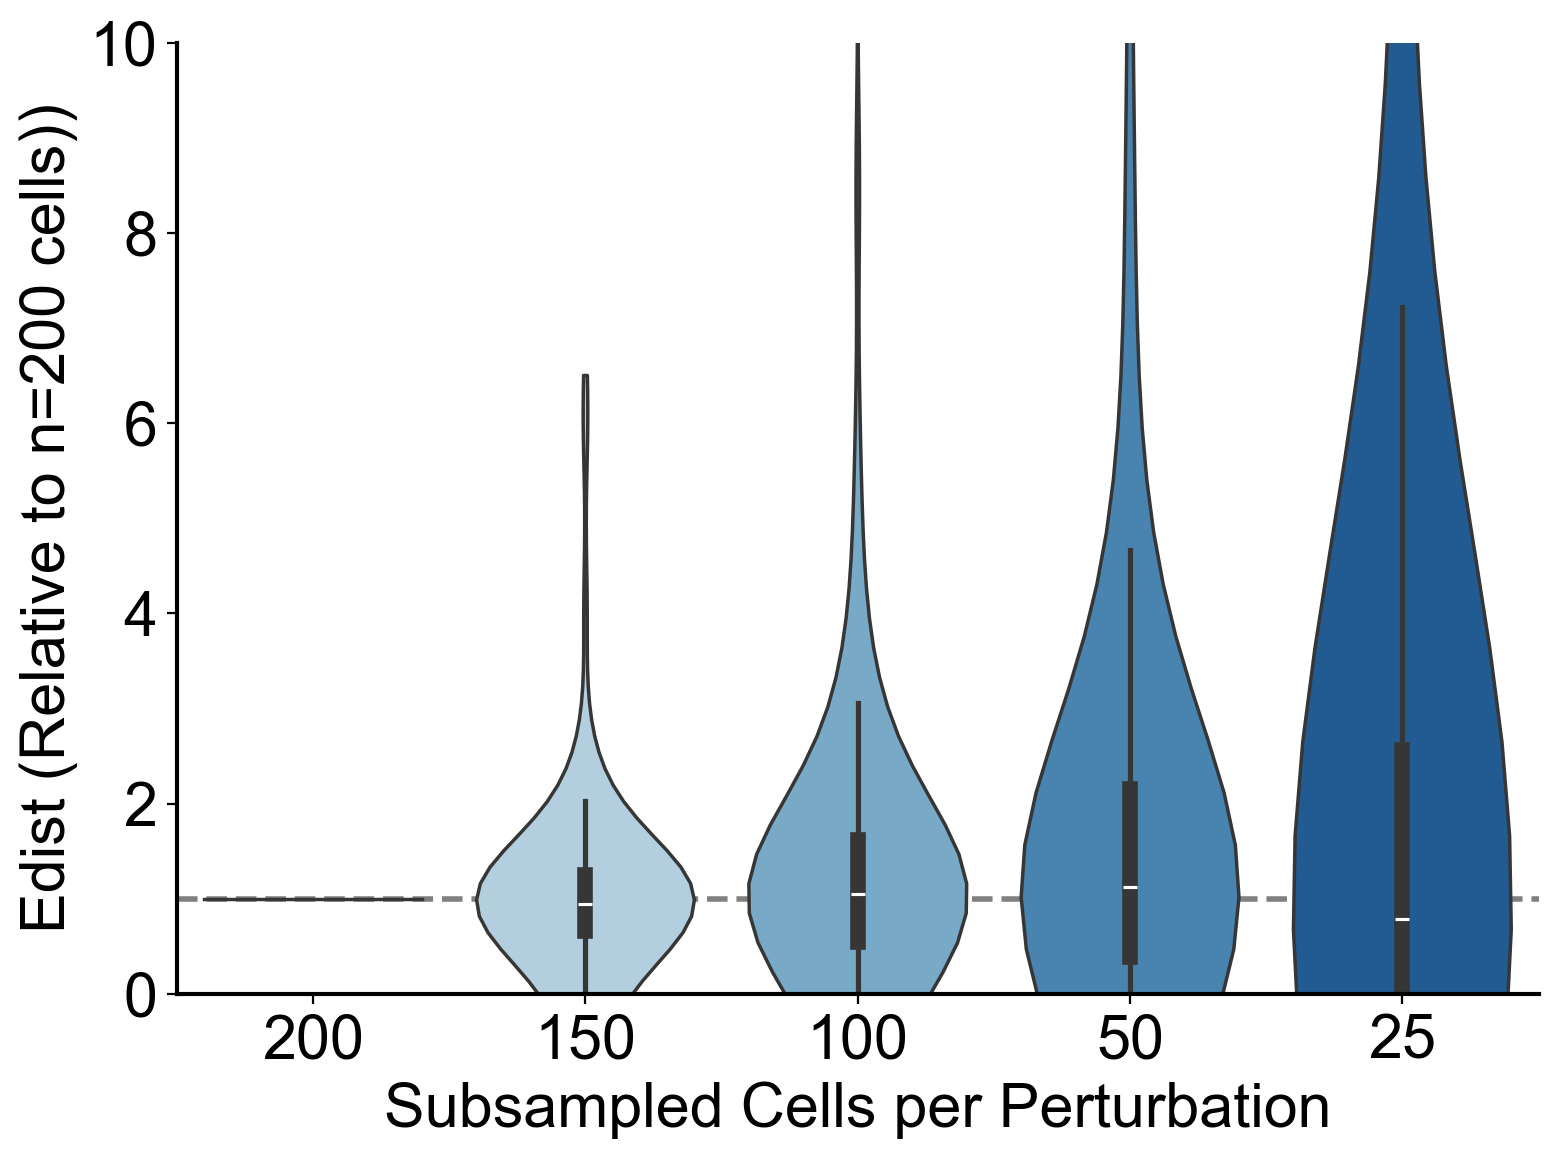

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gather edist per condition
estats_dfs = {
    "estats_200": estats_200,
    "estats_150": estats_150,
    "estats_100": estats_100,
    "estats_50": estats_50,
    "estats_25": estats_25,
}

def get_edist_series(df: pd.DataFrame) -> pd.Series:
    return df["edist"] if "edist" in df.columns else pd.Series(dtype=float)

# Prepare data for relative edist (for all but 200)
base = get_edist_series(estats_dfs["estats_200"]).copy()
records = []

order = [
    ("estats_200", "200"),
    ("estats_150", "150"),
    ("estats_100", "100"),
    ("estats_50", "50"),
    ("estats_25", "25"),
]

# Add 200 condition (always exactly 1.0)
# For perturbations in base, relative_edist == 1
records.append(
    pd.DataFrame({
        "condition": "200",
        "relative_edist": [1.0] * len(base)
    })
)

# Add other conditions relative to 200
for key, label in order:
    if label == "200":
        continue  # already added
    s = get_edist_series(estats_dfs[key]).rename("cond")
    merged = pd.DataFrame({"base": base}).join(s, how="inner")
    if not merged.empty:
        relative_edist = merged["cond"] / merged["base"]
        records.append(pd.DataFrame({"condition": label, "relative_edist": relative_edist.values}))

plot_df = pd.concat(records, ignore_index=True) if len(records) else pd.DataFrame({"condition": [], "relative_edist": []})

# Violin plot of relative edist (condition / 200), also show 200 == 1.0
plt.figure(figsize=(8, 6))
order_labels = [label for _, label in order]
ax = sns.violinplot(
    x="condition",
    y="relative_edist",
    data=plot_df,
    order=order_labels,
    palette="Blues",
    scale="width",
    cut=0,
)

plt.xlabel("Subsampled Cells per Perturbation", fontsize=22)
plt.ylabel("Edist (Relative to n=200 cells))", fontsize=22)
plt.xticks(rotation=0, fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0, 10)
plt.title("", fontsize=16)

# Add horizontal reference line at 1 (since ratio)
plt.axhline(1, color="gray", linestyle="--", linewidth=2, zorder=0)

# Style to match previous barplot
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/psp/notebooks/figs/relative_edist_violin_by_cells.svg")
plt.show()


In [1]:
import pandas as pd
protospacer_calls_file = "/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/KOLF_Perturbation_Atlas_Analysis/input_files/protospacer_calls_per_cell.csv"
protospacer_calls = pd.read_csv(protospacer_calls_file)

In [ ]:
all_feature_calls = []
for feature_call in protospacer_calls['feature_call'].unique():
    all_feature_calls.extend(feature_call.split('|'))
all_feature_calls = pd.Series(all_feature_calls).str.strip()
all_feature_calls = all_feature_calls.unique()
feature_counts = {feature:{"1":0,"2":0,"3":0,"4":0,"5":0,"6+":0} for feature in all_feature_calls}
for feature_call in protospacer_calls['feature_call']:
    features = feature_call.split('|')
    n_features = len(features)
    if n_features >= 6:
        n_features = "6+"
    for feature in features:
        feature_counts[feature][str(n_features)] += 1

feature_counts_df = pd.DataFrame(feature_counts)

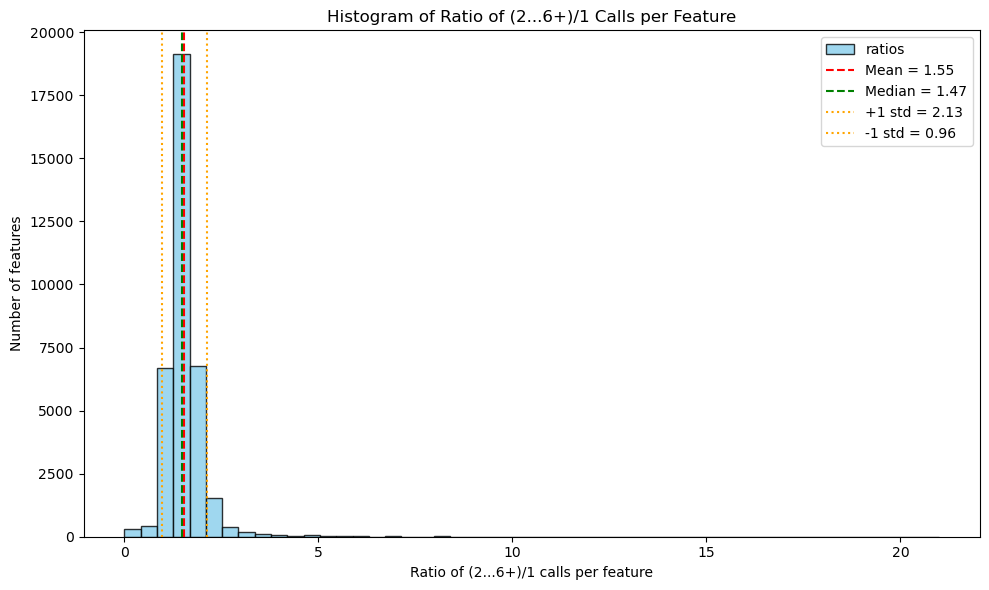

In [10]:
# Compute the ratio of sum(2...6+)/1 for each feature (column)
feature_counts_df = pd.DataFrame(feature_counts)
numerator = feature_counts_df.loc[["2", "3", "4", "5", "6+"]].sum(axis=0)
denominator = feature_counts_df.loc["1"]
ratio = numerator / denominator
ratio.name = "ratio_of_2_to_6plus_over_1"
ratio_df = ratio.to_frame()
ratio_df.replace([float('inf'), float('nan')], 0, inplace=True)
ratio_df.fillna(0, inplace=True)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

values = ratio_df["ratio_of_2_to_6plus_over_1"].values

# Plot histogram
n, bins, patches = plt.hist(values, bins=50, color='skyblue', edgecolor='black', alpha=0.8, label="ratios")

# Calculate statistics
mean_val = np.mean(values)
median_val = np.median(values)
std_val = np.std(values)

# Plot statistics as vertical lines
plt.axvline(mean_val, color='red', linestyle='--', label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color='green', linestyle='--', label=f"Median = {median_val:.2f}")
plt.axvline(mean_val+std_val, color='orange', linestyle=':', label=f"+1 std = {mean_val+std_val:.2f}")
plt.axvline(mean_val-std_val, color='orange', linestyle=':', label=f"-1 std = {mean_val-std_val:.2f}")

plt.xlabel("Ratio of (2...6+)/1 calls per feature")
plt.ylabel("Number of features")
plt.title("Histogram of Ratio of (2...6+)/1 Calls per Feature")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Compute the sum per row
row_sums = feature_counts_df.sum(axis=1)
row_sums

1     2735450
2     2229908
3     1083189
4      430712
5      162905
6+     119978
dtype: int64

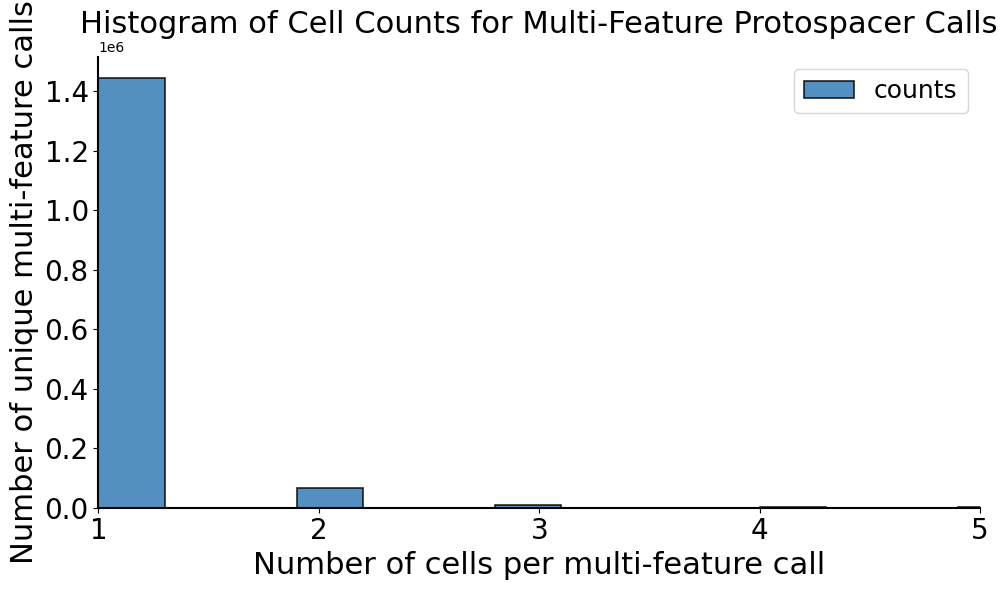

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Count multi-feature calls (calls containing '|')
multi_feature_call_counts = (
    protospacer_calls[protospacer_calls['feature_call'].str.contains('\|', regex=True)]['feature_call']
    .value_counts()
)
values = multi_feature_call_counts.values

plt.figure(figsize=(10, 6))
bars = plt.hist(
    values,
    bins=50,
    color="#367CB7",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.85,
    label="counts"
)

# Only calculate and show the median
median_val = np.median(values)

plt.xlabel("Number of cells per multi-feature call", fontsize=22)
plt.ylabel("Number of unique multi-feature calls", fontsize=22)
plt.title("Histogram of Cell Counts for Multi-Feature Protospacer Calls", fontsize=22)
plt.xticks([1, 2, 3, 4, 5], fontsize=20)
plt.yticks(fontsize=20)

# Add axes stylings
ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.grid(False)

plt.legend(fontsize=18)
plt.tight_layout()
plt.xlim(1,5)
plt.show()